<a href="https://colab.research.google.com/github/Nanikore123/CapstoneProject_K5_B1/blob/main/Capstone_K5_B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Capstone Project K5-B1**

Topik: "Personalisasi Pengalaman Mobile Banking Berbasis Analitik & AI"

Judul: "Pengembangan Prototipe Sistem Personalisasi Mobile Banking untuk Meningkatkan Engagement Nasabah Berbasis Analitik dan AI"

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In [ ]:
np.random.seed(42)
n = 10000

activities = [
    "transfer",           # Transfer (fitur utama, paling sering)
    "bills_topup",        # Bills & Top Up (tagihan + top-up)
    "qris_payment",       # QRIS Tap (dari tab Transactions)
    "wealth_investment",  # Investment (dari tab Products)
    "low_activity"        # jarang pakai
]

products = [
    "savings_deposito",   # Savings & Deposito
    "investment",         # Investment (reksa dana, obligasi)
    "loans_credit_card",  # Loans & Credit Cards
    "octo_pay",           # OCTO Pay (e-wallet)
    "gopay_linked"        # GoPay (linked e-wallet)
]

customer_types = [
    "nasabah reguler",
    "nasabah privat",
    "nasabah prioritas"
]

data = pd.DataFrame({
    "user_id": np.arange(1, n+1),
    "age": np.random.randint(18, 60, n),

    "monthly_income": np.random.randint(3000000, 50000000, n),

    "occupation": np.random.choice(
        ["student", "employee", "entrepreneur", "freelancer"],
        n,
        p=[0.15, 0.55, 0.20, 0.10]
    ),

    "avg_balance": np.random.randint(500000, 100000000, n),
    "transaction_frequency_monthly": np.random.randint(5, 120, n),
    "transfer_ratio":  np.round(np.random.uniform(0.2, 0.9, n), 2),
    "payment_ratio":   np.round(np.random.uniform(0.1, 0.8, n), 2),
    "qris_ratio":      np.round(np.random.uniform(0.0, 0.6, n), 2),
    "topup_ratio":     np.round(np.random.uniform(0.0, 0.5, n), 2),

    "investment_activity":  np.random.choice([0, 1], n, p=[0.65, 0.35]),
    "loan_usage":           np.random.choice([0, 1], n, p=[0.60, 0.40]),
    "credit_card_usage":    np.random.choice([0, 1], n, p=[0.60, 0.40]),
    "cardless_usage":       np.random.choice([0, 1], n, p=[0.75, 0.25]),
    "poin_xtra_active":     np.random.choice([0, 1], n, p=[0.60, 0.40]),
    "login_frequency_weekly":    np.random.randint(3, 50, n),
    "avg_session_duration_min":  np.random.randint(1, 15, n),

    "preferred_channel": np.random.choice(
        ["mobile_app", "internet_banking"],
        n,
        p=[0.88, 0.12]
    ),

    "device_type": np.random.choice(
        ["android", "ios"],
        n,
        p=[0.78, 0.22]
    ),

    "city_tier": np.random.choice(
        ["tier_1", "tier_2", "tier_3"],
        n,
        p=[0.55, 0.30, 0.15]
    ),

    "recent_transaction_days": np.random.randint(0, 30, n),

    "dominant_activity": np.random.choice(
        activities,
        n,
        p=[0.35, 0.25, 0.20, 0.12, 0.08]
    ),

    "frequent_product": np.random.choice(
        products,
        n,
        p=[0.30, 0.20, 0.20, 0.15, 0.15]
    ),

    "customer_type": np.random.choice(
        customer_types,
        n,
        p=[0.70, 0.20, 0.10]
    )
})

file_path = "/content/mobile_banking_enhanced_dataset_weighted.csv"
data.to_csv(file_path, index=False)

data["consent_given"] = np.random.choice(
    [True, False], size=len(data), p=[0.85, 0.15]
)
print(f"Saved to: {file_path}")
print(f"User dengan consent : {data['consent_given'].sum():,}")
print(f"User tanpa consent  : {(~data['consent_given']).sum():,}")

Saved to: /content/mobile_banking_enhanced_dataset_weighted.csv
User dengan consent : 8,497
User tanpa consent  : 1,503


# Preprocessing Dataset

In [ ]:
data.head()

,user_id,age,monthly_income,occupation,avg_balance,transaction_frequency_monthly,transfer_ratio,payment_ratio,qris_ratio,topup_ratio,...,login_frequency_weekly,avg_session_duration_min,preferred_channel,device_type,city_tier,recent_transaction_days,dominant_activity,frequent_product,customer_type,consent_given
0,1,56,21167395,entrepreneur,57384374,117,0.63,0.36,0.55,0.42,...,7,9,mobile_app,android,tier_1,28,transfer,savings_deposito,nasabah reguler,True
1,2,46,44667756,entrepreneur,5773346,87,0.37,0.17,0.18,0.16,...,34,5,mobile_app,ios,tier_1,3,bills_topup,savings_deposito,nasabah prioritas,True
2,3,32,43682512,employee,46753495,27,0.32,0.21,0.58,0.24,...,32,1,mobile_app,ios,tier_1,2,qris_payment,savings_deposito,nasabah privat,True
3,4,25,44868484,student,2975891,82,0.24,0.60,0.50,0.20,...,16,11,mobile_app,android,tier_1,16,transfer,investment,nasabah reguler,True
4,5,38,36422146,employee,58521945,21,0.23,0.37,0.41,0.22,...,19,9,mobile_app,android,tier_3,28,qris_payment,gopay_linked,nasabah reguler,True


In [ ]:
data.describe()

,user_id,age,monthly_income,avg_balance,transaction_frequency_monthly,transfer_ratio,payment_ratio,qris_ratio,topup_ratio,investment_activity,loan_usage,credit_card_usage,cardless_usage,poin_xtra_active,login_frequency_weekly,avg_session_duration_min,recent_transaction_days
count,10000.00000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,38.546400,2.634901e+07,5.045403e+07,61.541000,0.54924,0.450753,0.299797,0.250502,0.355900,0.3970,0.395800,0.255300,0.389500,25.879800,7.398700,14.511200
std,2886.89568,12.014287,1.353854e+07,2.845846e+07,33.549773,0.20259,0.202120,0.172630,0.143416,0.478809,0.4893,0.489046,0.436052,0.487661,13.541724,4.033158,8.653275
min,1.00000,18.000000,3.003212e+06,5.357230e+05,5.000000,0.20000,0.100000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000
25%,2500.75000,28.000000,1.456547e+07,2.626499e+07,32.000000,0.37000,0.280000,0.150000,0.130000,0.000000,0.0000,0.000000,0.000000,0.000000,14.000000,4.000000,7.000000
50%,5000.50000,39.000000,2.632180e+07,5.006918e+07,62.000000,0.55000,0.450000,0.300000,0.250000,0.000000,0.0000,0.000000,0.000000,0.000000,26.000000,7.000000,15.000000
75%,7500.25000,49.000000,3.798851e+07,7.497275e+07,91.000000,0.73000,0.630000,0.450000,0.370000,1.000000,1.0000,1.000000,1.000000,1.000000,38.000000,11.000000,22.000000
max,10000.00000,59.000000,4.999831e+07,9.999982e+07,119.000000,0.90000,0.800000,0.600000,0.500000,1.000000,1.0000,1.000000,1.000000,1.000000,49.000000,14.000000,29.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        10000 non-null  int64  
 1   age                            10000 non-null  int64  
 2   monthly_income                 10000 non-null  int64  
 3   occupation                     10000 non-null  object 
 4   avg_balance                    10000 non-null  int64  
 5   transaction_frequency_monthly  10000 non-null  int64  
 6   transfer_ratio                 10000 non-null  float64
 7   payment_ratio                  10000 non-null  float64
 8   qris_ratio                     10000 non-null  float64
 9   topup_ratio                    10000 non-null  float64
 10  investment_activity            10000 non-null  int64  
 11  loan_usage                     10000 non-null  int64  
 12  credit_card_usage              10000 non-null  

In [ ]:
data.isnull().sum()

,0
user_id,0
age,0
monthly_income,0
occupation,0
avg_balance,0
transaction_frequency_monthly,0
transfer_ratio,0
payment_ratio,0
qris_ratio,0
topup_ratio,0


In [ ]:
data["dominant_activity"].value_counts()
data["frequent_product"].value_counts()
data["customer_type"].value_counts()

,count
customer_type,
nasabah reguler,7006
nasabah privat,2007
nasabah prioritas,987


Untuk ngelihat sebaran kategori user, misal berapa bamyak user yang sering pakek fitur A, B, ataaupun C.

In [ ]:
le = LabelEncoder()

data["dominant_activity_enc"] = le.fit_transform(data["dominant_activity"])
data["frequent_product_enc"] = le.fit_transform(data["frequent_product"])
data["customer_type_enc"] = le.fit_transform(data["customer_type"])

# Simpan mapping untuk explainability nanti
activity_mapping = {i: v for i, v in
    enumerate(sorted(data["dominant_activity"].unique()))}
product_mapping = {i: v for i, v in
    enumerate(sorted(data["frequent_product"].unique()))}

print("dominant_activity mapping:", activity_mapping)
print("frequent_product mapping:", product_mapping)

dominant_activity mapping: {0: 'bills_topup', 1: 'low_activity', 2: 'qris_payment', 3: 'transfer', 4: 'wealth_investment'}
frequent_product mapping: {0: 'gopay_linked', 1: 'investment', 2: 'loans_credit_card', 3: 'octo_pay', 4: 'savings_deposito'}


Ngubah data kategorikal jadi numerik.
K-Means hanya bisa memproses data numerik. LabelEncoder ngubah, "investment_active"=0, "low_activity"=1, "payment_heavy"=2, dst. Kemudian mapping disimpan agar nanti bisa digunakan untuk penjelasan rekomendasi (explainability).

# Clustering Features

In [ ]:
features = [
    "transaction_frequency_monthly",     # seberapa aktif bertransaksi
    "avg_balance",                       # ukuran kekayaan/aset
    "transfer_ratio",                    # dominasi transfer
    "payment_ratio",                     # dominasi bayar tagihan
    "qris_ratio",                        # dominasi qris
    "topup_ratio",                       # dominasi top-up/e-wallet
    "investment_activity",               # aktif investasi atau tidak
    "loan_usage",                        # penggunaan pinjaman
    "credit_card_usage",                 # penggunaan kartu kredit
    "cardless_usage",                    # penggunaan cardless
    "poin_xtra_active",                  # xtra point
    "login_frequency_weekly",            # seberapa sering buka app
    "avg_session_duration_min",          # seberapa lama per sesi
    "recent_transaction_days",           # seberapa baru aktivitasnya
    "dominant_activity_enc",             # *** fitur baru dari encode ***
    "frequent_product_enc",              # *** fitur baru dari encode ***
    "customer_type_enc"                  # *** fitur baru dari encode ***
]

X = data[features]
print(f"Jumlah fitur yang digunakan: {len(features)}")
print("Fitur:", features)

Jumlah fitur yang digunakan: 17
Fitur: ['transaction_frequency_monthly', 'avg_balance', 'transfer_ratio', 'payment_ratio', 'qris_ratio', 'topup_ratio', 'investment_activity', 'loan_usage', 'credit_card_usage', 'cardless_usage', 'poin_xtra_active', 'login_frequency_weekly', 'avg_session_duration_min', 'recent_transaction_days', 'dominant_activity_enc', 'frequent_product_enc', 'customer_type_enc']


Jadi disini fitur yang dipakek ituu udah dalam bentuk data numerik semua.

# Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape setelah scaling:", X_scaled.shape)

Shape setelah scaling: (10000, 17)


Kalo gk discaling nnti dia bakal ada gap yg jauh di fitur yg dipakek.
Karena skala angkanya beda jauh*.

Jadi, disini fitur2nya diubah biar rata2 = 0 dan standar deviasi = 1.

Variance explained per komponen (%):
  PC1: 6.31%
  PC2: 6.25%
  PC3: 6.18%
  PC4: 6.10%
  PC5: 6.08%
Total: 30.9%


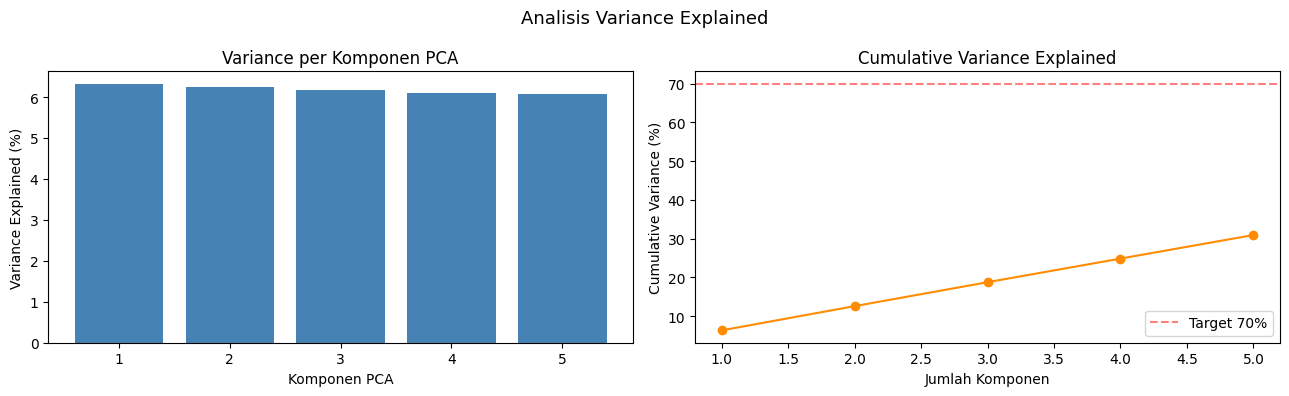

In [ ]:
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("Variance explained per komponen (%):")
for i, v in enumerate(explained):
    print(f"  PC{i+1}: {v*100:.2f}%")
print(f"Total: {explained.sum()*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(1, len(explained)+1), explained*100, color="steelblue")
ax1.set_xlabel("Komponen PCA")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Variance per Komponen PCA")

ax2.plot(range(1, len(explained)+1),
         np.cumsum(explained)*100, marker="o", color="darkorange")
ax2.axhline(y=70, color="red", linestyle="--", alpha=0.5, label="Target 70%")
ax2.set_xlabel("Jumlah Komponen")
ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_title("Cumulative Variance Explained")
ax2.legend()

plt.suptitle("Analisis Variance Explained", fontsize=13)
plt.tight_layout()
plt.show()

Ngurangin dimensi data yang awalnya 17 fitur jadi 5 fitur. Jadi, ada 5 fitur yang dapat definisiin variasi data.

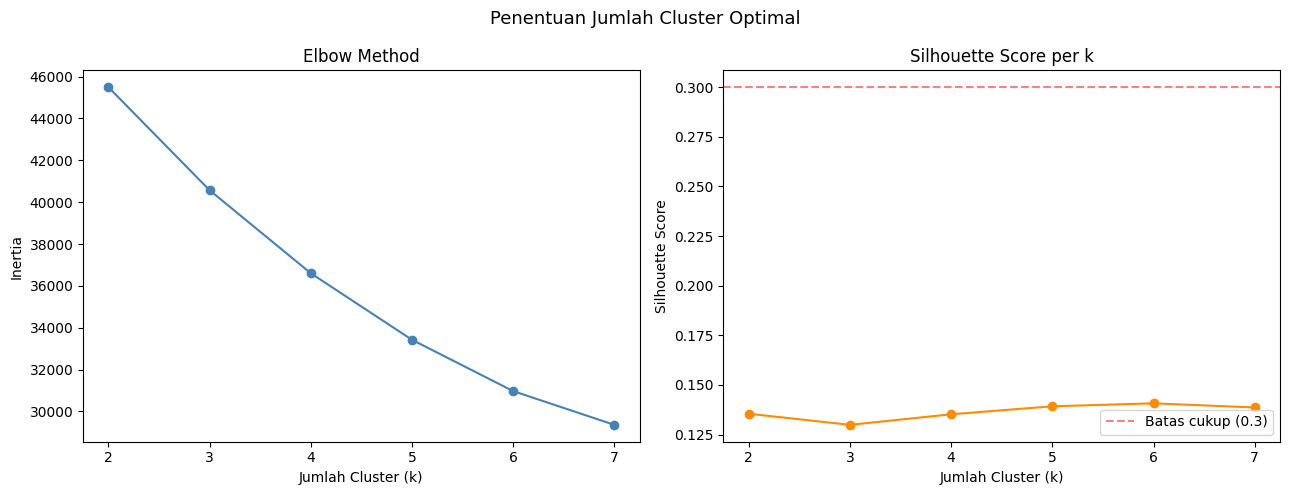

k terbaik berdasarkan silhouette score: 6
Silhouette score: 0.1407


In [ ]:
inertia = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_pca)
    inertia.append(model.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(k_range, inertia, marker="o", color="steelblue")
ax1.set_xlabel("Jumlah Cluster (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(k_range, sil_scores, marker="o", color="darkorange")
ax2.axhline(y=0.3, color="red", linestyle="--", alpha=0.5, label="Batas cukup (0.3)")
ax2.set_xlabel("Jumlah Cluster (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score per k")
ax2.legend()

plt.suptitle("Penentuan Jumlah Cluster Optimal", fontsize=13)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"k terbaik berdasarkan silhouette score: {best_k}")
print(f"Silhouette score: {max(sil_scores):.4f}")

Nyari jumlah cluster terbaik biar optimal. Jadi ada 6 cluster terbaik.

Note:
- Inertia, untuk liat seberapa rapat titik dalam satu clusternta, makin kecil makin bagus.
- Silhouette score, untuk liat seberapa jelas jarak tiap clusternya (misah atau enggaknya), makin tinggi makin baik (skala -1 sampai 1).

## Final Clustering

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)

final_score = silhouette_score(X_pca, data["cluster"])
print(f"Silhouette Score final: {final_score:.4f}")
print("\nInterpretasi:")
print("  > 0.5   = cluster bagus (well-separated)")
print("  0.3–0.5 = cluster cukup baik")
print("  < 0.3   = cluster masih overlap")

print("\nDistribusi cluster:")
print(data["cluster"].value_counts().sort_index())

Silhouette Score final: 0.1407

Interpretasi:
  > 0.5   = cluster bagus (well-separated)
  0.3–0.5 = cluster cukup baik
  < 0.3   = cluster masih overlap

Distribusi cluster:
cluster
0    1591
1    1799
2    1688
3    1736
4    1561
5    1625
Name: count, dtype: int64


Note:
- Clustering dengan k terbaik (fit_predict())*
- Karena hasil evaluasinya 0.14, artinya cluster yang terbentuk masih memiliki overlap antar kelompok.

/tmp/ipykernel_4557/3446515098.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = get_cmap("tab10")


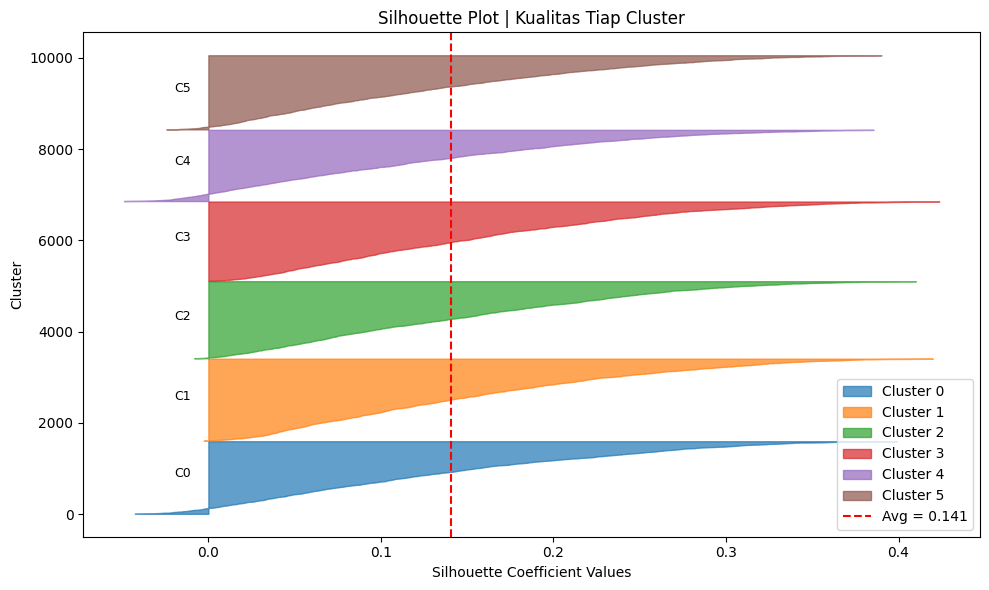

In [ ]:
from matplotlib.cm import get_cmap

sample_sil = silhouette_samples(X_pca, data["cluster"])
fig, ax = plt.subplots(figsize=(10, 6))
colors = get_cmap("tab10")
y_lower = 10

for i in range(best_k):
    vals = np.sort(sample_sil[data["cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     alpha=0.7, color=colors(i), label=f"Cluster {i}")
    ax.text(-0.02, y_lower + 0.5 * len(vals), f"C{i}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=final_score, color="red", linestyle="--",
           label=f"Avg = {final_score:.3f}")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot | Kualitas Tiap Cluster")
ax.legend()
plt.tight_layout()
plt.show()

Visualisasi kualitas tiap Clustrnya.*
Jadi, Ssmakin mendekati angka 1 (semkain lebar) maka cluster semakin bagus, sedangkan kalau mendekati 0 berarti cluster saling overlap antar kelompoknya. Nilai positif berarti data point berada di cluster yang tepat, nilai negatif berarti data point lebih dekat ke cluster lain (salah masuk). Garis merah putus-putus itu rata-rata keseluruhan.

/tmp/ipykernel_4557/3081772474.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_pca[mask, 0], X_pca[mask, 1],


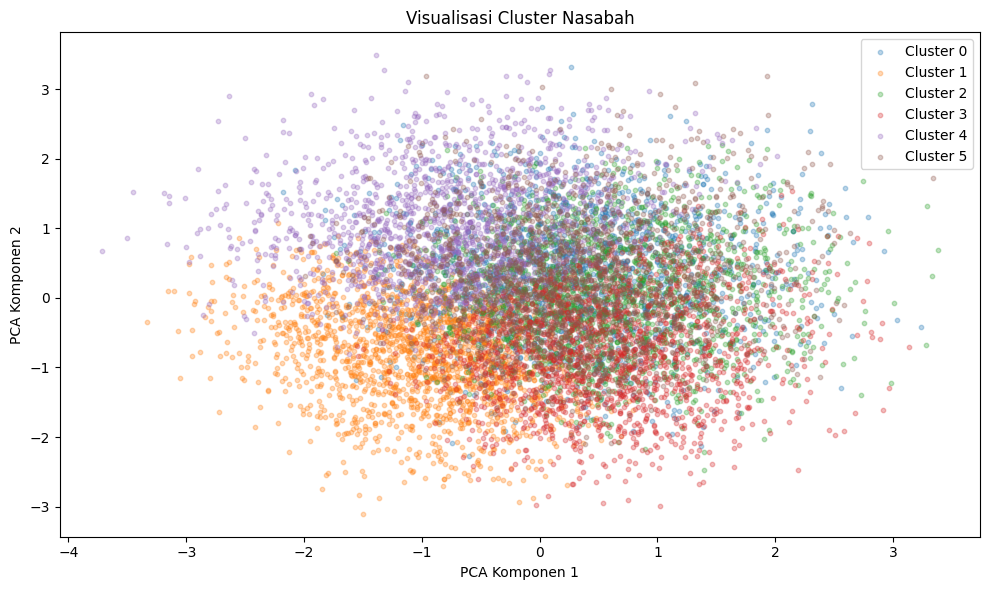

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.colormaps["tab10"]

for c in sorted(data["cluster"].unique()):
    mask = data["cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors(c), label=f"Cluster {c}",
                alpha=0.3, s=10)

plt.xlabel("PCA Komponen 1")
plt.ylabel("PCA Komponen 2")
plt.title("Visualisasi Cluster Nasabah")
plt.legend()
plt.tight_layout()
plt.show()

Visualisasi pengelompokkan cluster.*
Untuk ngeliat clusternya sudah pada misah atau masih nyampur. Jadi dari visualisasi, beberapa cluster masih ada yang berdekatan (makanya overlap).

# Segment Labeling

In [ ]:
# Analisis karakteristik tiap cluster
cluster_profile = data.groupby("cluster")[features].mean()
print("=== Profil rata-rata tiap cluster ===")
print(cluster_profile[[
    "transaction_frequency_monthly",
    "avg_balance",
    "topup_ratio",
    "payment_ratio",
    "investment_activity",
    "dominant_activity_enc"
]].round(3))

# Decode dominant_activity untuk tiap cluster
cluster_activity = data.groupby("cluster")["dominant_activity"].agg(
    lambda x: x.value_counts().index[0]
)
print("\nDominant activity paling umum per cluster:")
print(cluster_activity)

=== Profil rata-rata tiap cluster ===
         transaction_frequency_monthly   avg_balance  topup_ratio  \
cluster                                                             
0                               64.215  5.949086e+07        0.197   
1                               48.496  3.297823e+07        0.216   
2                               51.152  4.269350e+07        0.264   
3                               58.074  7.314286e+07        0.210   
4                               73.688  4.642498e+07        0.252   
5                               76.193  4.864648e+07        0.370   

         payment_ratio  investment_activity  dominant_activity_enc  
cluster                                                             
0                0.484                0.383                  2.408  
1                0.393                0.317                  2.106  
2                0.434                0.409                  1.806  
3                0.460                0.244                  1.5

Untuk mahamin karakteristik masing-masing cluster berdasarkan rata-rata fitur utama.


Hasil Analisis:

*   Cluster 0: payment_ratio cukup tinggi (0.484), transfer dominan → bill_payer
*   Cluster 1: avg_balance terendah (33 jt), semua metrik paling rendah → low_activity
*   Cluster 2: investment_activity tinggi (0.409), bills_topup dominan → investor
*   Cluster 3: avg_balance tertinggi (73 jt), payment & bills_topup dominan → bill_payer (balance besar tapi investment rendah 0.244)
*   Cluster 4: investment_activity tertinggi (0.489), aktif bertransaksi → investor
*   Cluster 5: tx terbanyak (76/bulan), topup_ratio & payment_ratio tertinggi → digital_spender


Jadi hasil rekomendasinya itu:


*   "bill_payer",
*   "low_activity",
*   "investor",
*   "bill_payer",
*   "investor",
*   "digital_spender"

In [ ]:
# Mapping berdasarkan output cluster_profile di atas:
# =========================================================================
# - Cluster 0: payment_ratio cukup tinggi (0.484), transfer dominan
#            → bill_payer
# - Cluster 1: avg_balance terendah (33 jt), semua metrik paling rendah
#            → low_activity
# - Cluster 2: investment_activity tinggi (0.409), bills_topup dominan
#            → investor
# - Cluster 3: avg_balance tertinggi (73 jt), payment & bills_topup dominan
#            → bill_payer (balance besar tapi investment rendah 0.244)
# - Cluster 4: investment_activity tertinggi (0.489), aktif bertransaksi
#            → investor
# - Cluster 5: tx terbanyak (76/bulan), topup_ratio & payment_ratio tertinggi
#            → digital_spender
# =========================================================================

segment_map = {
    0: "bill_payer",
    1: "low_activity",
    2: "investor",
    3: "bill_payer",
    4: "investor",
    5: "digital_spender"
}

data["segment"] = data["cluster"].map(segment_map)
print("\nDistribusi segmen:")
print(data["segment"].value_counts())


Distribusi segmen:
segment
bill_payer         3327
investor           3249
low_activity       1799
digital_spender    1625
Name: count, dtype: int64


Mayoritas nasabah berada pada segmen digital spender dan bill payer.*

In [ ]:
print("\nCek null di kolom segment:")
print(data["segment"].isnull().sum())


Cek null di kolom segment:
0


Karena hasilnya = 0, jadi semua data berhasil dapat label segment tanpa ada nilai kosong (NaN).

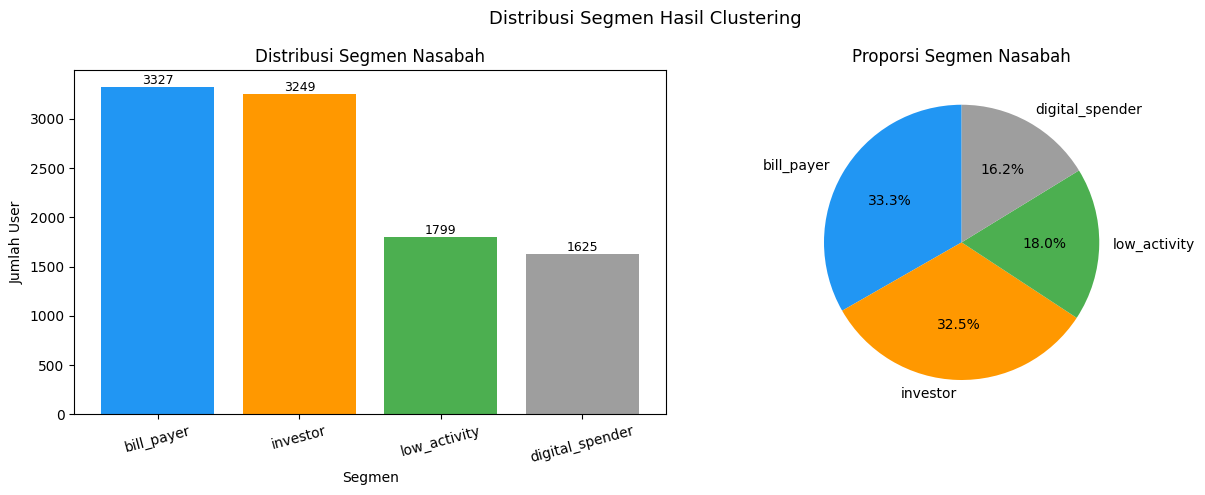

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
seg_counts = data["segment"].value_counts()
colors_bar = ["#2196F3", "#FF9800", "#4CAF50", "#9E9E9E"]
bars = ax1.bar(seg_counts.index, seg_counts.values, color=colors_bar)
ax1.set_title("Distribusi Segmen Nasabah")
ax1.set_xlabel("Segmen")
ax1.set_ylabel("Jumlah User")
ax1.tick_params(axis="x", rotation=15)
for bar, v in zip(bars, seg_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(v), ha="center", fontsize=9)

# Pie chart
ax2.pie(seg_counts.values, labels=seg_counts.index,
        colors=colors_bar, autopct="%1.1f%%", startangle=90)
ax2.set_title("Proporsi Segmen Nasabah")

plt.suptitle("Distribusi Segmen Hasil Clustering", fontsize=13)
plt.tight_layout()
plt.show()

Visualisasi Distribusi Segemen, Bar chart dan pie chart untuk lihat jumlah dan proporsi tiap segmen nasabah.*

Jadi, terlihat bahwa digital spender dan bill payer mendominasi populasi user.

# Rule-Based Personalization

In [ ]:
def recommendation(row):
    if not row["consent_given"]:
        return "rekomendasi tidak tersedia"
    recs = {
        "digital_spender": "promo cashback QRIS Tap & Bills Top Up",
        "bill_payer":      "promo cashback tagihan & auto-debit bulanan",
        "investor":        "promo reksa dana & Savings Deposito OCTO",
        "low_activity":    "gratis biaya transfer & eksplorasi fitur OCTO"
    }
    return recs.get(row["segment"], "rekomendasi umum")

# Explainable AI
def explain_recommendation(row):
    if not row["consent_given"]:
        return "User belum memberikan consent untuk personalisasi."

    segment = row["segment"]
    tf      = row["transaction_frequency_monthly"]
    qris    = row["qris_ratio"]
    topup   = row["topup_ratio"]
    payment = row["payment_ratio"]
    invest  = row["investment_activity"]

    if segment == "digital_spender":
        return (
            f"Berdasarkan riwayat transaksi Anda, kami melihat Anda aktif "
            f"menggunakan QRIS Tap dan Bills & Top Up ({tf}x/bulan). "
            f"Rekomendasi ini dipilih khusus agar Anda bisa hemat lebih banyak "
            f"setiap kali bertransaksi digital via OCTO."
        )
    elif segment == "bill_payer":
        return (
            f"Anda tercatat rutin melakukan pembayaran tagihan setiap bulannya. "
            f"Dengan cashback otomatis untuk setiap tagihan yang dibayar melalui "
            f"fitur Bills & Top Up, Anda bisa mendapatkan manfaat lebih dari "
            f"transaksi yang sudah biasa Anda lakukan."
        )
    elif segment == "investor":
        return (
            f"Profil Anda menunjukkan ketertarikan pada produk wealth management. "
            f"Produk reksa dana dan Savings & Deposito di tab Products OCTO "
            f"bisa menjadi pilihan untuk mengoptimalkan pertumbuhan aset Anda."
        )
    else:
        return (
            f"Kami melihat aktivitas digital banking Anda masih bisa dioptimalkan. "
            f"Mulai eksplorasi fitur Transfer dan QRIS-Tap kami tanpa biaya admin, "
            f"untuk membantu Anda semakin nyaman bertransaksi di OCTO."
        )

data["recommendation"]          = data.apply(recommendation, axis=1)
data["why_this_recommendation"] = data.apply(explain_recommendation, axis=1)

print(data[["segment", "recommendation"]].value_counts())
print("\nContoh penjelasan (5 user pertama):")
for i, row in data.head(5).iterrows():
    print(f"  User {row['user_id']}: {row['why_this_recommendation']}")

segment          recommendation                               
bill_payer       promo cashback tagihan & auto-debit bulanan      2826
investor         promo reksa dana & Savings Deposito OCTO         2739
low_activity     gratis biaya transfer & eksplorasi fitur OCTO    1551
digital_spender  promo cashback QRIS Tap & Bills Top Up           1381
investor         rekomendasi tidak tersedia                        510
bill_payer       rekomendasi tidak tersedia                        501
low_activity     rekomendasi tidak tersedia                        248
digital_spender  rekomendasi tidak tersedia                        244
Name: count, dtype: int64

Contoh penjelasan (5 user pertama):
  User 1: Profil Anda menunjukkan ketertarikan pada produk wealth management. Produk reksa dana dan Savings & Deposito di tab Products OCTO bisa menjadi pilihan untuk mengoptimalkan pertumbuhan aset Anda.
  User 2: Profil Anda menunjukkan ketertarikan pada produk wealth management. Produk reksa dana dan S

Definisiin fungsi 'alasan rekomendasi'.

# Prediksi User Baru

In [ ]:
# Simulasi dengan (3 User baru dengan profile yang berbeda):
new_users = pd.DataFrame([
    {
        "transaction_frequency_monthly": 8,
        "avg_balance":                   85000000,
        "transfer_ratio":                0.15,
        "payment_ratio":                 0.20,
        "qris_ratio":                    0.05,
        "topup_ratio":                   0.05,
        "investment_activity":           1,
        "loan_usage":                    0,
        "credit_card_usage":             1,
        "cardless_usage":                0,
        "poin_xtra_active":              1,
        "login_frequency_weekly":        6,
        "avg_session_duration_min":      13,
        "recent_transaction_days":       2,
        "dominant_activity_enc":         4,
        "frequent_product_enc":          1,
        "customer_type_enc":             1
    },
    {
        "transaction_frequency_monthly": 95,
        "avg_balance":                   4000000,
        "transfer_ratio":                0.25,
        "payment_ratio":                 0.20,
        "qris_ratio":                    0.45,
        "topup_ratio":                   0.40,
        "investment_activity":           0,
        "loan_usage":                    0,
        "credit_card_usage":             0,
        "cardless_usage":                1,
        "poin_xtra_active":              1,
        "login_frequency_weekly":        35,
        "avg_session_duration_min":      9,
        "recent_transaction_days":       1,
        "dominant_activity_enc":         2,
        "frequent_product_enc":          0,
        "customer_type_enc":             0
    },
    {
        "transaction_frequency_monthly": 5,
        "avg_balance":                   800000,
        "transfer_ratio":                0.50,
        "payment_ratio":                 0.25,
        "qris_ratio":                    0.05,
        "topup_ratio":                   0.10,
        "investment_activity":           0,
        "loan_usage":                    0,
        "credit_card_usage":             0,
        "cardless_usage":                0,
        "poin_xtra_active":              0,
        "login_frequency_weekly":        3,
        "avg_session_duration_min":      2,
        "recent_transaction_days":       28,
        "dominant_activity_enc":         1,
        "frequent_product_enc":          4,
        "customer_type_enc":             0
    }
])

# User baru diasumsikan sudah consent saat onboarding
new_users["consent_given"] = True

# Pipeline Transform
new_scaled   = scaler.transform(new_users[features])
new_pca      = pca.transform(new_scaled)
new_labels   = kmeans.predict(new_pca)
new_segments = [segment_map[c] for c in new_labels]
new_users["segment"] = new_segments
new_users["recommendation"]          = new_users.apply(recommendation, axis=1)
new_users["why_this_recommendation"] = new_users.apply(explain_recommendation, axis=1)

print("=== Hasil Prediksi User Baru ===")
for i, row in new_users.iterrows():
    print(f"\n  User {i+1}:")
    print(f"    Segmen      : {row['segment']}")
    print(f"    Rekomendasi : {row['recommendation']}")
    print(f"    Alasan      : {row['why_this_recommendation']}")

=== Hasil Prediksi User Baru ===

  User 1:
    Segmen      : low_activity
    Rekomendasi : gratis biaya transfer & eksplorasi fitur OCTO
    Alasan      : Kami melihat aktivitas digital banking Anda masih bisa dioptimalkan. Mulai eksplorasi fitur Transfer dan QRIS-Tap kami tanpa biaya admin, untuk membantu Anda semakin nyaman bertransaksi di OCTO.

  User 2:
    Segmen      : investor
    Rekomendasi : promo reksa dana & Savings Deposito OCTO
    Alasan      : Profil Anda menunjukkan ketertarikan pada produk wealth management. Produk reksa dana dan Savings & Deposito di tab Products OCTO bisa menjadi pilihan untuk mengoptimalkan pertumbuhan aset Anda.

  User 3:
    Segmen      : low_activity
    Rekomendasi : gratis biaya transfer & eksplorasi fitur OCTO
    Alasan      : Kami melihat aktivitas digital banking Anda masih bisa dioptimalkan. Mulai eksplorasi fitur Transfer dan QRIS-Tap kami tanpa biaya admin, untuk membantu Anda semakin nyaman bertransaksi di OCTO.


Untuk memprediksi segment user baru dengan alur yang sama*

# Single Customer View

In [ ]:
single_customer_view = data[[
    "user_id", "age", "monthly_income",
    "avg_balance", "transaction_frequency_monthly",
    "dominant_activity", "frequent_product", "customer_type",
    "consent_given",
    "segment", "recommendation", "why_this_recommendation"
]].copy()

single_customer_view.head()

single_customer_view.to_csv(
    "/content/single_customer_view.csv", index=False
)
print(f"Total user          : {len(single_customer_view):,}")
print(f"User dengan consent : {single_customer_view['consent_given'].sum():,}")
print(f"User tanpa consent  : {(~single_customer_view['consent_given']).sum():,}")

Total user          : 10,000
User dengan consent : 8,497
User tanpa consent  : 1,503


Ini contoh*

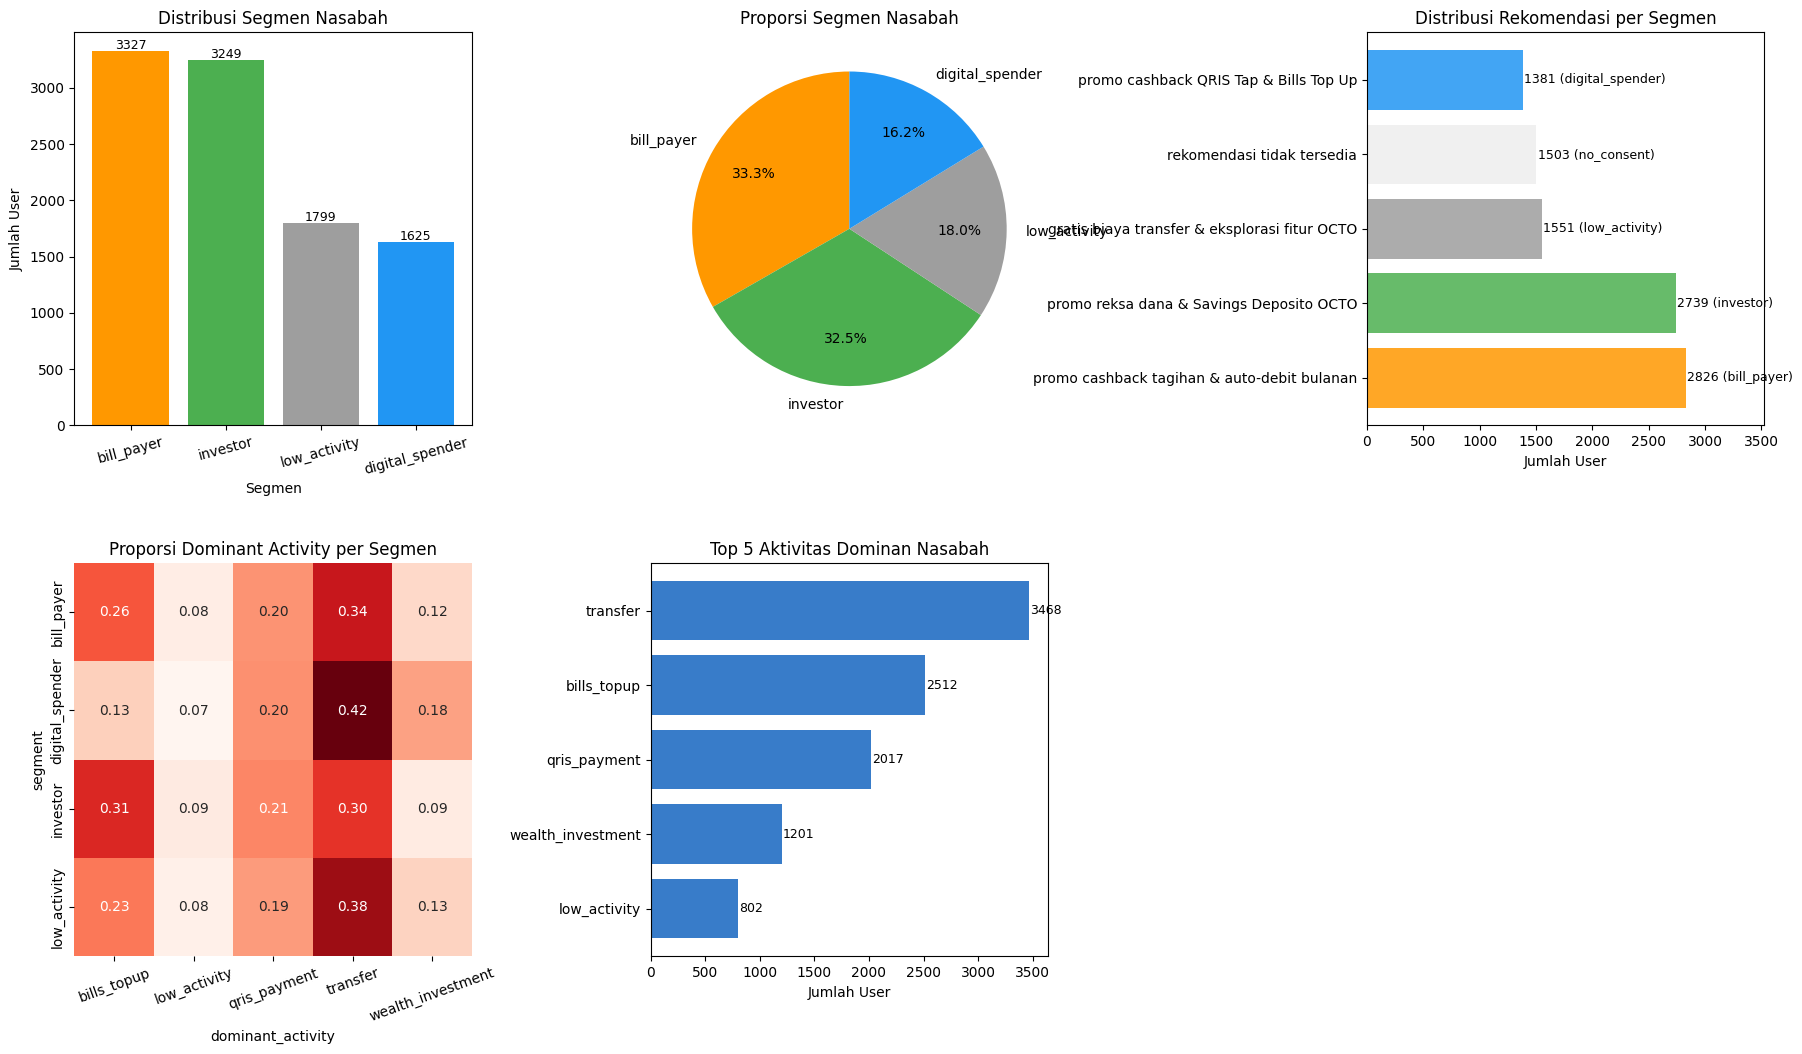

In [ ]:
fig = plt.figure(figsize=(20, 12))

# Plot 1: Distribusi Segmen (Bar)
ax1 = fig.add_subplot(2, 3, 1)
seg_counts  = data["segment"].value_counts()
colors_seg  = {
    "digital_spender": "#2196F3",
    "bill_payer":       "#FF9800",
    "investor":         "#4CAF50",
    "low_activity":     "#9E9E9E",
    "no_consent":       "#EEEEEE"
}
bar_colors = [colors_seg.get(s, "#CCCCCC") for s in seg_counts.index]
bars = ax1.bar(seg_counts.index, seg_counts.values, color=bar_colors)
ax1.set_title("Distribusi Segmen Nasabah")
ax1.set_xlabel("Segmen")
ax1.set_ylabel("Jumlah User")
ax1.tick_params(axis="x", rotation=15)
for bar, v in zip(bars, seg_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20, str(v),
             ha="center", fontsize=9)

# Plot 2: Proporsi Segmen (Pie chart)
ax2 = fig.add_subplot(2, 3, 2)
ax2.pie(seg_counts.values, labels=seg_counts.index,
        colors=bar_colors, autopct="%1.1f%%", startangle=90, labeldistance=1.12,
        pctdistance=0.7,)
ax2.set_title("Proporsi Segmen Nasabah")

# Plot 3: Distribusi Rekomendasi (Horizontal Bar) ─
ax3 = fig.add_subplot(2, 3, 3)

recommendation_segmentMap = {
    "promo cashback QRIS Tap & Bills Top Up": "digital_spender",
    "promo cashback tagihan & auto-debit bulanan": "bill_payer",
    "promo reksa dana & Savings Deposito OCTO": "investor",
    "gratis biaya transfer & eksplorasi fitur OCTO": "low_activity",
    "rekomendasi tidak tersedia":                   "no_consent"
}

rec_counts = data["recommendation"].value_counts()
rec_colors = [colors_seg.get(recommendation_segmentMap.get(r, "no_consent"), "#CCCCCC")
    for r in rec_counts.index]

bars = ax3.barh(
    rec_counts.index,
    rec_counts.values,
    color=rec_colors,
    alpha=0.85
)
ax3.set_title("Distribusi Rekomendasi per Segmen")
ax3.set_xlabel("Jumlah User")
for i, (rec, v) in enumerate(zip(rec_counts.index, rec_counts.values)):
    segment_name = recommendation_segmentMap.get(rec, "no_consent")
    ax3.text(v + 10, i, f"{v} ({segment_name})", va="center", fontsize=9)

ax3.set_xlim(0, max(rec_counts.values) + 700)

# Plot 4: Heatmap Dominant Activity per Segmen
ax4 = fig.add_subplot(2, 3, 4)
cross_tab = pd.crosstab(
    data["segment"], data["dominant_activity"], normalize="index"
)
sns.heatmap(cross_tab, ax=ax4, cmap="Reds",
            annot=True, fmt=".2f", cbar=False)
ax4.set_title("Proporsi Dominant Activity per Segmen")
ax4.tick_params(axis="x", rotation=20)

# Plot 5: Top 5 Fitur Terpopuler
ax5 = fig.add_subplot(2, 3, 5)
top_features = data["dominant_activity"].value_counts().head(5)
ax5.barh(top_features.index[::-1], top_features.values[::-1],
         color="#1565C0", alpha=0.85)
ax5.set_title("Top 5 Aktivitas Dominan Nasabah")
ax5.set_xlabel("Jumlah User")
for i, v in enumerate(top_features.values[::-1]):
    ax5.text(v + 10, i, str(v), va="center", fontsize=9)

plt.subplots_adjust(
    wspace=0.45,
    hspace=0.35
)
plt.subplots_adjust(
    wspace=0.45,
    hspace=0.35
)

pos = ax3.get_position()

ax3.set_position([
    pos.x0 + 0.07,
    pos.y0,
    pos.width,
    pos.height
])

plt.show()

1.   Distribusi Segmen Nasabah

Visualisasi ini menunjukkan jumlah user pada masing-masing segmen hasil clustering. Dari hasil tersebut terlihat bahwa segmen bill_payer dan investor mendominasi jumlah nasabah, sedangkan segmen low_activity memiliki jumlah paling sedikit. Hal ini menunjukkan bahwa sebagian besar user cukup aktif menggunakan layanan mobile banking, baik untuk pembayaran tagihan maupun aktivitas investasi.

2.   Proporsi Segmen Nasabah

Pie chart digunakan untuk melihat persentase atau proporsi tiap segmen terhadap keseluruhan user. Terlihat bahwa segmen bill_payer dan investor memiliki proporsi terbesar, sedangkan digital_spender dan low_activity memiliki proporsi yang lebih kecil. Visualisasi ini membantu memahami komposisi perilaku user secara umum pada dataset.

3.   Distribusi Rekomendasi per Segmen

Visualisasi ini menunjukkan jumlah user yang menerima masing-masing jenis rekomendasi berdasarkan hasil segmentasi nasabah. Warna pada tiap bar disesuaikan dengan warna segmen agar lebih mudah melihat hubungan antara rekomendasi dan kategori user terkait. Dari hasil visualisasi terlihat bahwa rekomendasi promo cashback tagihan dan produk investasi memiliki jumlah user paling banyak karena segmen bill_payer dan investor mendominasi populasi data. Visualisasi ini masih bersifat general karena rekomendasi diberikan berdasarkan kelompok segmen, bukan berdasarkan perilaku personal tiap individu secara real-time.

4.   Proporsi Dominant Activity per Segmen

Heatmap ini digunakan untuk melihat aktivitas dominan pada masing-masing segmen nasabah. Semakin gelap warna pada suatu kotak, maka semakin besar proporsi aktivitas tersebut pada segmen terkait. Dari visualisasi terlihat bahwa aktivitas transfer dan bills_topup cukup mendominasi hampir di semua segmen, sedangkan aktivitas wealth_investment dan low_activity memiliki proporsi yang lebih kecil. Visualisasi ini membantu memahami pola perilaku utama user pada tiap segmen hasil clustering.

5.   Top 5 Aktivitas Dominan Nasabah

Visualisasi ini menunjukkan aktivitas yang paling sering dilakukan oleh user pada aplikasi mobile banking. Aktivitas transfer menjadi fitur yang paling dominan digunakan, kemudian diikuti oleh bills_topup dan qris_payment. Hal ini menunjukkan bahwa mayoritas user masih menggunakan aplikasi mobile banking untuk kebutuhan transaksi harian, pembayaran digital, dan transaksi cepat berbasis QRIS.





# Backend Integration*

In [ ]:
joblib.dump(scaler,       "/content/scaler.pkl")
joblib.dump(pca,          "/content/pca_model.pkl")
joblib.dump(kmeans,       "/content/kmeans_model.pkl")
joblib.dump(segment_map,  "/content/segment_map.pkl")

print("Model berhasil disimpan:")
print("  - scaler.pkl       → StandardScaler")
print("  - pca_model.pkl    → PCA transformer")
print("  - kmeans_model.pkl → K-Means model")
print("  - segment_map.pkl  → mapping cluster → nama segmen")

print("\nUrutan inference di backend:")
print("  1. Input fitur user baru (17 fitur)")
print("  2. scaler.transform()   → normalisasi")
print("  3. pca.transform()      → reduksi dimensi")
print("  4. kmeans.predict()     → nomor cluster")
print("  5. segment_map[cluster] → nama segmen")
print("  6. recommendation(row)  → rekomendasi")
print("  7. explain_recommendation(row) → alasan")

Model berhasil disimpan:
  - scaler.pkl       → StandardScaler
  - pca_model.pkl    → PCA transformer
  - kmeans_model.pkl → K-Means model
  - segment_map.pkl  → mapping cluster → nama segmen

Urutan inference di backend:
  1. Input fitur user baru (17 fitur)
  2. scaler.transform()   → normalisasi
  3. pca.transform()      → reduksi dimensi
  4. kmeans.predict()     → nomor cluster
  5. segment_map[cluster] → nama segmen
  6. recommendation(row)  → rekomendasi
  7. explain_recommendation(row) → alasan


Untuk Integrasi nanti download file di sidebar kiri*

# Note:

- Colab ini masih bersifat kasaran (walau begitu bisa dikatakan sudah final, jadi masih diperlukan penyesuaiaan dan lainnya)